In [3]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [4]:
## Loading the dataset
df = pd.read_csv('train.csv')
df

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,9276_01,Europa,False,A/98/P,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,Gravior Noxnuther,False
8689,9278_01,Earth,True,G/1499/S,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,Kurta Mondalley,False
8690,9279_01,Earth,False,G/1500/S,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,Fayey Connon,True
8691,9280_01,Europa,False,E/608/S,55 Cancri e,32.0,False,0.0,1049.0,0.0,353.0,3235.0,Celeon Hontichre,False


In [5]:
# 1. Extract Group Size from PassengerId (gggg_pp)
passenger_groups = df['PassengerId'].apply(lambda x: x.split('_')[0])
group_sizes = passenger_groups.value_counts()
df['GroupSize'] = passenger_groups.map(group_sizes)

In [6]:
# 2. Extract Deck and Side from Cabin (deck/num/side)
# We fill NaNs temporarily with a placeholder string to split without errors
df['Cabin'] = df['Cabin'].fillna('Missing/Missing/Missing')
df['CabinDeck'] = df['Cabin'].apply(lambda x: x.split('/')[0])
df['CabinSide'] = df['Cabin'].apply(lambda x: x.split('/')[2])

# Revert placeholder back to actual NaN so the Imputer can handle it cleanly later
df['CabinDeck'] = df['CabinDeck'].replace('Missing', np.nan)
df['CabinSide'] = df['CabinSide'].replace('Missing', np.nan)

In [7]:
# 3. Total luxury spending across amenities
spending_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
df['TotalSpent'] = df[spending_cols].sum(axis=1, min_count=0)

In [8]:
# Drop raw unhelpful text identifiers
df.drop(columns=['PassengerId', 'Cabin', 'Name'], inplace=True)

# Separate features and target
X_all = df.drop(columns=['Transported'])
# Convert True/False target into numeric 1/0 for the neural network
y_all = df['Transported'].astype(int).values
df

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,GroupSize,CabinDeck,CabinSide,TotalSpent
0,Europa,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,False,1,B,P,0.0
1,Earth,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,True,1,F,S,736.0
2,Europa,False,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,False,2,A,S,10383.0
3,Europa,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,False,2,A,S,5176.0
4,Earth,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,True,1,F,S,1091.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,Europa,False,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,False,1,A,P,8536.0
8689,Earth,True,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,False,1,G,S,0.0
8690,Earth,False,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,True,1,G,S,1873.0
8691,Europa,False,55 Cancri e,32.0,False,0.0,1049.0,0.0,353.0,3235.0,False,2,E,S,4637.0


In [9]:
# Create a 70% Train, 15% Validation, 15% Test split
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_all, y_all, test_size=0.15, random_state=42, stratify=y_all
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.1765, random_state=42, stratify=y_train_val
)

In [10]:
categorical_features = ['HomePlanet', 'CryoSleep', 'VIP', 'CabinDeck', 'CabinSide']
numerical_features = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'GroupSize', 'TotalSpent']

# Categorical transformer: Impute missing values with the most common class, then encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', sparse_output=False))
])

# Numerical transformer: Impute missing values with the median, then scale
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Combine into a single engine
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_features),
        ('num', numerical_transformer, numerical_features)
    ]
)

# Fit exclusively on train, transform all
X_train = preprocessor.fit_transform(X_train).astype('float32')
# Check the dynamic shape generated by the OneHotEncoder expansions
print(f"Number of input features after encoding: {X_train.shape[1]}")

X_val = preprocessor.transform(X_val).astype('float32')
X_test = preprocessor.transform(X_test).astype('float32')

Number of input features after encoding: 20


In [11]:
## Creating the ANN model
model = Sequential([
    Dense(64, activation = 'relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(32, activation = 'relu'),
    Dropout(0.2),
    Dense(1, activation = 'sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
## Importing loss function and optimizer
import tensorflow
opt = tensorflow.keras.optimizers.Adam(learning_rate = 0.01)
loss = tensorflow.keras.losses.BinaryCrossentropy()

In [13]:
## Compiling the model
model.compile(optimizer = opt, loss = loss, metrics = ['accuracy'])

In [14]:
## Training the model
history=model.fit(
    X_train, y_train,
    validation_data = (X_val, y_val),
    epochs = 100,
    verbose = 1,
    batch_size = 64
)

Epoch 1/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7763 - loss: 0.4698 - val_accuracy: 0.7962 - val_loss: 0.4377
Epoch 2/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7945 - loss: 0.4357 - val_accuracy: 0.7985 - val_loss: 0.4365
Epoch 3/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7940 - loss: 0.4266 - val_accuracy: 0.8023 - val_loss: 0.4430
Epoch 4/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8005 - loss: 0.4219 - val_accuracy: 0.7969 - val_loss: 0.4391
Epoch 5/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7977 - loss: 0.4206 - val_accuracy: 0.7946 - val_loss: 0.4296
Epoch 6/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8018 - loss: 0.4147 - val_accuracy: 0.8054 - val_loss: 0.4249
Epoch 7/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8000 - loss: 0.4154 - val_accuracy: 0.7977 - val_loss: 0.4282
Epoch 8/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8037 - loss: 0.4110 - val_accuracy: 0.7962 - v

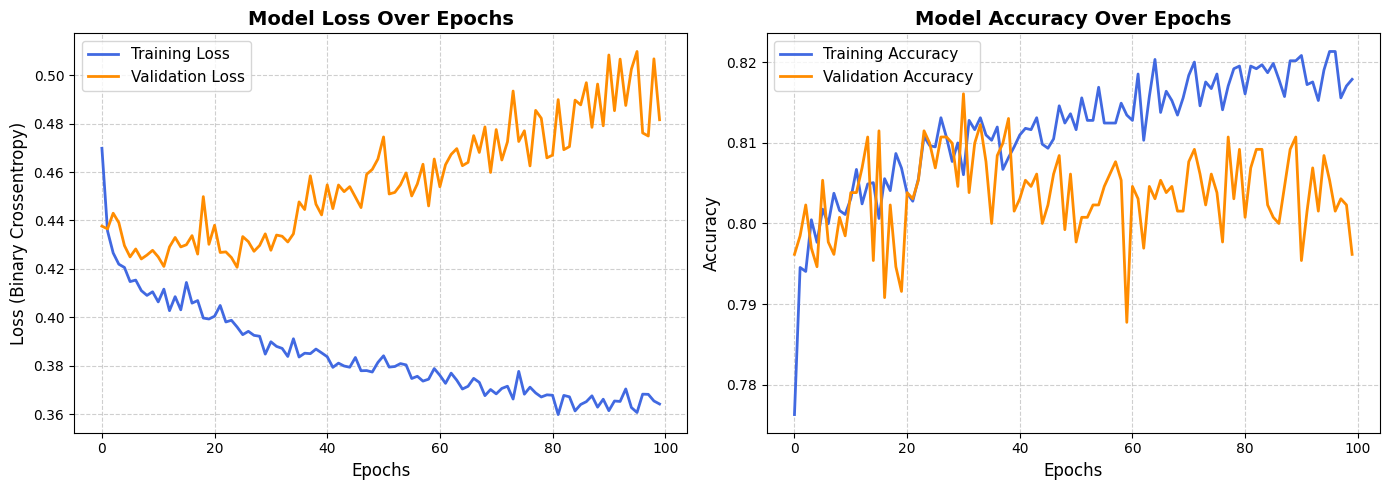

In [15]:
import matplotlib.pyplot as plt

# Create a figure with 2 subplots side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 1. Loss Curves Graph
ax1.plot(history.history['loss'], label='Training Loss', color='royalblue', linewidth=2)
ax1.plot(history.history['val_loss'], label='Validation Loss', color='darkorange', linewidth=2)
ax1.set_title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epochs', fontsize=12)
ax1.set_ylabel('Loss (Binary Crossentropy)', fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.6)

# 2. Accuracy Curves Graph
ax2.plot(history.history['accuracy'], label='Training Accuracy', color='royalblue', linewidth=2)
ax2.plot(history.history['val_accuracy'], label='Validation Accuracy', color='darkorange', linewidth=2)
ax2.set_title('Model Accuracy Over Epochs', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epochs', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [16]:
import pickle

# Save the preprocessor object
with open('preprocessor.pkl', 'wb') as f:
    pickle.dump(preprocessor, f)

print("Preprocessor saved to 'preprocessor.pkl'")

Preprocessor saved to 'preprocessor.pkl'
